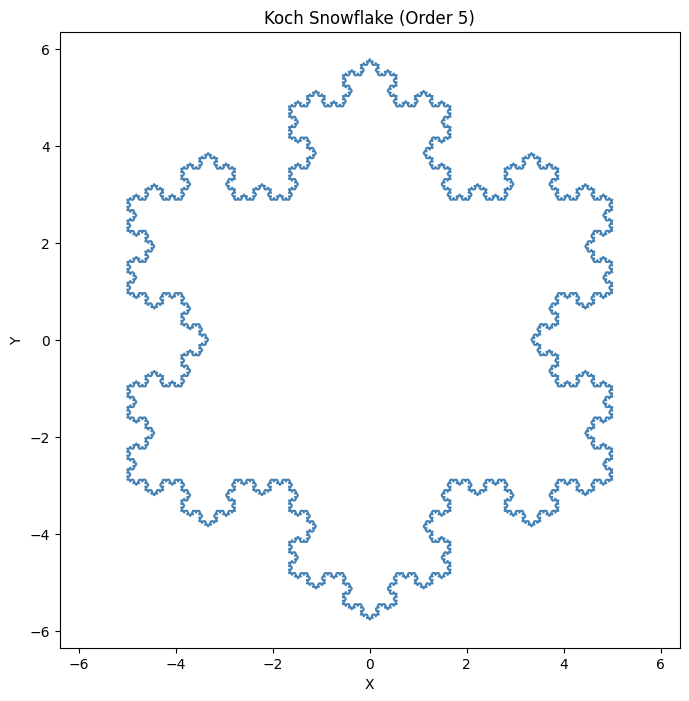

In [2]:
import matplotlib.pyplot as plt
import numpy as np

def koch_snowflake(order, scale=10):
    def _koch_snowflake_complex(order):
        if order == 0:
            angles = np.array([0, 120, 240]) + 90
            return scale / np.sqrt(3) * np.exp(np.deg2rad(angles) * 1j)
        else:
            Z_rotation = 0.5 - 0.5j * np.sqrt(3) / 3
            prev_points = _koch_snowflake_complex(order - 1)
            next_points = np.roll(prev_points, -1)
            delta = next_points - prev_points
            new_points = np.empty(len(prev_points) * 4, dtype=np.complex128)
            new_points[::4] = prev_points
            new_points[1::4] = prev_points + delta / 3
            new_points[2::4] = prev_points + delta * Z_rotation
            new_points[3::4] = prev_points + delta * 2 / 3
            return new_points

    points = _koch_snowflake_complex(order)
    points = np.append(points, points[0])  
    x, y = points.real, points.imag
    return x, y

# Plotting
order = 5
x, y = koch_snowflake(order)

plt.figure(figsize=(8, 8))
plt.axis('equal')
plt.plot(x, y, color='steelblue')  
plt.title(f'Koch Snowflake (Order {order})')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()
